In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("09_used_car_price.csv")
df.head()

,car_age_years,km_driven,engine_cc,owners,price_lakh
0,10.0,109043.0,1183.0,2.0,4.0
1,14.0,157310.0,1292.0,1.0,2.5
2,11.0,66320.0,2915.0,1.0,9.1
3,3.0,197812.0,2773.0,2.0,6.8
4,8.0,135369.0,1458.0,2.0,7.9


In [2]:
# Shape of the dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:", df.columns.tolist())

# Data types of each column
print("\nData types:\n", df.dtypes)

# Basic statistics for numerical columns
df.describe()

Shape: (1020, 5)

Columns: ['car_age_years', 'km_driven', 'engine_cc', 'owners', 'price_lakh']

Data types:
 car_age_years    float64
km_driven        float64
engine_cc        float64
owners           float64
price_lakh       float64
dtype: object


,car_age_years,km_driven,engine_cc,owners,price_lakh
count,1010.000000,1009.000000,1010.000000,1010.000000,1020.000000
mean,7.551485,103868.322101,1911.020792,2.058416,6.552647
std,4.613487,56368.430427,634.674019,0.929397,3.350743
min,-2.000000,-10000.000000,803.000000,1.000000,-1.400000
25%,3.000000,57857.000000,1361.000000,1.000000,4.100000
50%,8.000000,102651.000000,1942.000000,2.000000,6.500000
75%,11.000000,154006.000000,2451.250000,3.000000,8.900000
max,15.000000,199977.000000,3000.000000,8.000000,16.400000


In [3]:
# Count missing values per column
print(df.isnull().sum())

# Percentage of missing values per column
print("\nPercentage missing:\n", (df.isnull().sum() / len(df)) * 100)

car_age_years    10
km_driven        11
engine_cc        10
owners           10
price_lakh        0
dtype: int64

Percentage missing:
 car_age_years    0.980392
km_driven        1.078431
engine_cc        0.980392
owners           0.980392
price_lakh       0.000000
dtype: float64


In [4]:
# Count of fully duplicated rows
print("Number of duplicate rows:", df.duplicated().sum())

# View the actual duplicate rows (if any)
df[df.duplicated()]

Number of duplicate rows: 20


,car_age_years,km_driven,engine_cc,owners,price_lakh
212,14.0,157310.0,1292.0,1.0,2.5
430,3.0,40587.0,949.0,1.0,10.7
553,13.0,106446.0,1846.0,3.0,3.6
583,3.0,134563.0,1454.0,2.0,8.9
584,2.0,53247.0,1671.0,3.0,10.1
587,2.0,107847.0,2240.0,2.0,9.6
604,14.0,82332.0,1022.0,2.0,2.0
620,12.0,178109.0,1517.0,1.0,0.3
634,9.0,48545.0,1049.0,1.0,8.6
653,4.0,102651.0,1714.0,3.0,8.3


In [5]:
# 1. Negative car age
print("Negative car_age_years:\n", df[df['car_age_years'] < 0])

# 2. Negative kilometers driven
print("\nNegative km_driven:\n", df[df['km_driven'] < 0])

# 3. Unrealistic owner counts
print("\nUnrealistic owners:\n", df[df['owners'] > 5])

# 4. Negative or zero price
print("\nNegative/zero price_lakh:\n", df[df['price_lakh'] <= 0])

Negative car_age_years:
      car_age_years  km_driven  engine_cc  owners  price_lakh
192           -2.0   136505.0     1741.0     3.0        -0.0
244           -2.0    19630.0     1218.0     1.0         9.3
261           -2.0   186778.0     2812.0     1.0         3.9
451           -2.0   199977.0      891.0     2.0         3.7
801           -2.0        NaN     1192.0     3.0         7.2

Negative km_driven:
      car_age_years  km_driven  engine_cc  owners  price_lakh
183            8.0   -10000.0     2757.0     1.0         8.5
428           11.0   -10000.0     1821.0     3.0         1.1
904            7.0   -10000.0     1265.0     1.0         7.8
934            2.0   -10000.0     1157.0     2.0        10.6
938           14.0   -10000.0     2104.0     3.0         6.9

Unrealistic owners:
      car_age_years  km_driven  engine_cc  owners  price_lakh
515           14.0   179476.0     2755.0     8.0         1.8
613            1.0   149506.0     2324.0     8.0         8.6
874            3

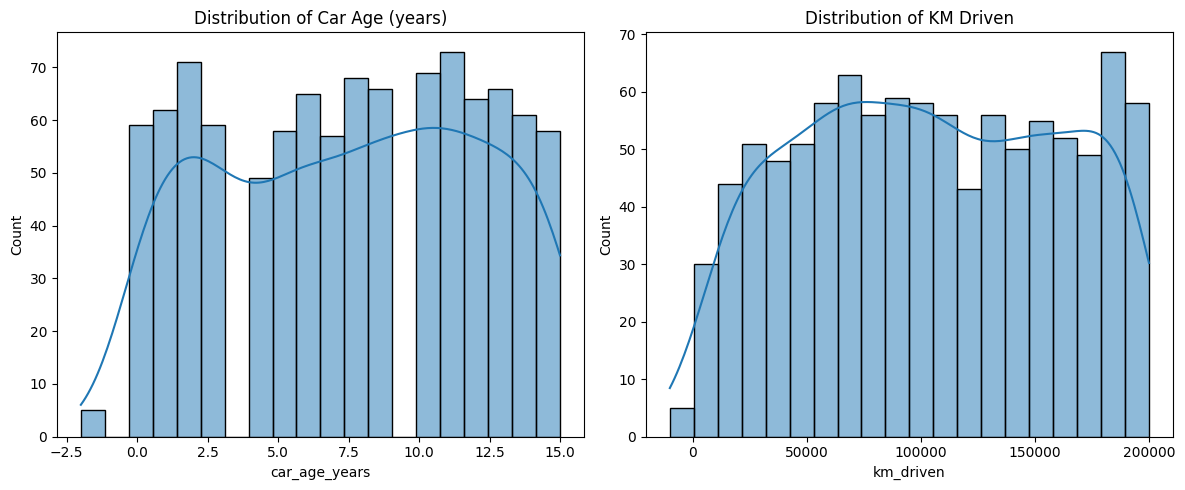

In [6]:
# Histograms for car_age_years and km_driven
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['car_age_years'], bins=20, ax=axes[0], kde=True)
axes[0].set_title('Distribution of Car Age (years)')

sns.histplot(df['km_driven'], bins=20, ax=axes[1], kde=True)
axes[1].set_title('Distribution of KM Driven')

plt.tight_layout()
plt.show()

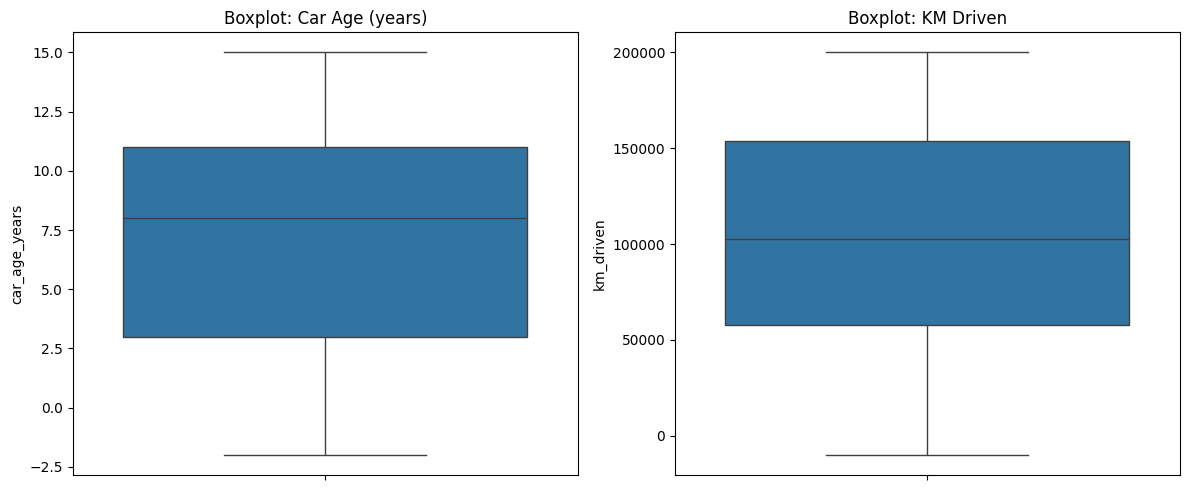

In [7]:
# Boxplots to spot outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=df['car_age_years'], ax=axes[0])
axes[0].set_title('Boxplot: Car Age (years)')

sns.boxplot(y=df['km_driven'], ax=axes[1])
axes[1].set_title('Boxplot: KM Driven')

plt.tight_layout()
plt.show()

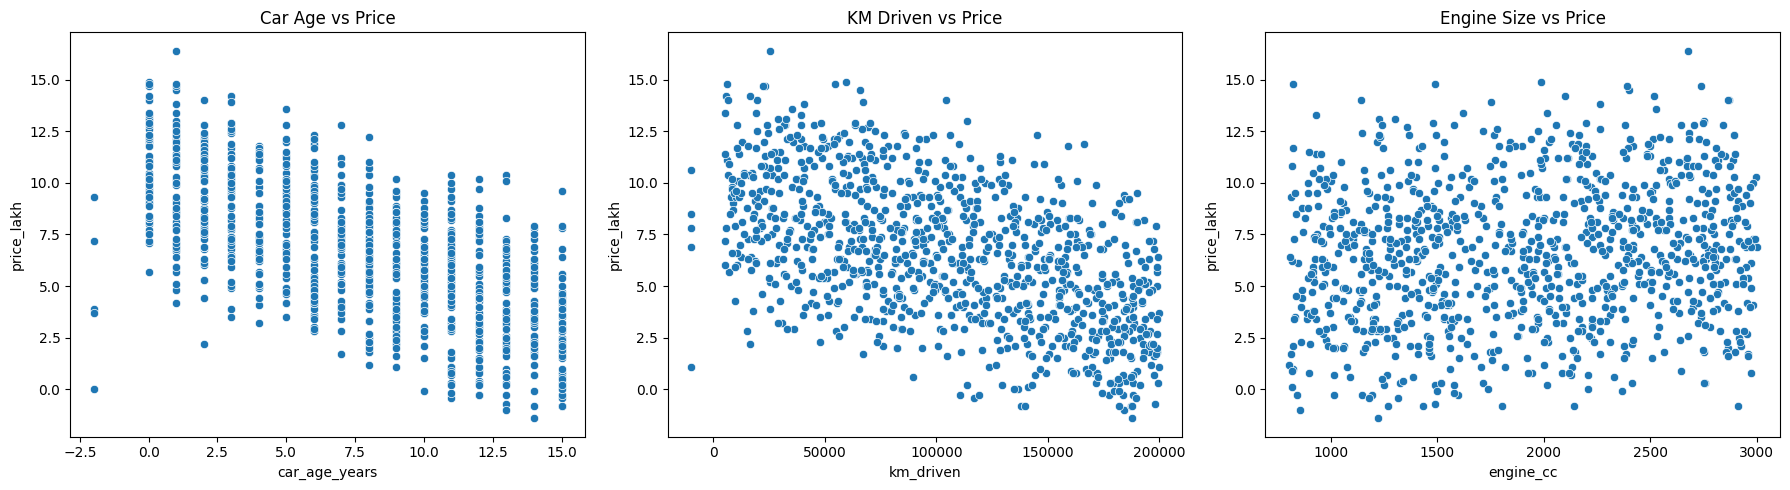

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=df['car_age_years'], y=df['price_lakh'], ax=axes[0])
axes[0].set_title('Car Age vs Price')

sns.scatterplot(x=df['km_driven'], y=df['price_lakh'], ax=axes[1])
axes[1].set_title('KM Driven vs Price')

sns.scatterplot(x=df['engine_cc'], y=df['price_lakh'], ax=axes[2])
axes[2].set_title('Engine Size vs Price')

plt.tight_layout()
plt.show()

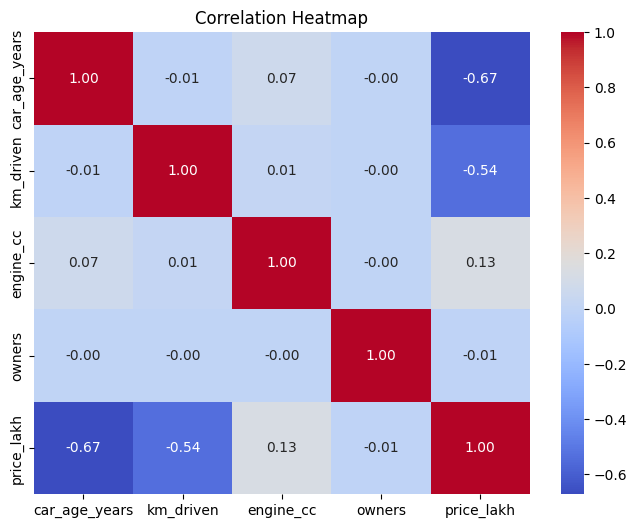

In [9]:
# Select only numeric columns and compute correlation
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [10]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

df = df[df['car_age_years'] >= 0]
print("Shape after removing negative car_age_years:", df.shape)

df = df[df['km_driven'] >= 0]
print("Shape after removing negative km_driven:", df.shape)

df = df[df['owners'] <= 5]
print("Shape after removing unrealistic owners:", df.shape)

df = df[df['price_lakh'] > 0]
print("Shape after removing invalid price_lakh:", df.shape)

Shape after removing duplicates: (1000, 5)
Shape after removing negative car_age_years: (985, 5)
Shape after removing negative km_driven: (972, 5)
Shape after removing unrealistic owners: (957, 5)
Shape after removing invalid price_lakh: (938, 5)


In [11]:
# Fill missing values with median for numeric column
for col in ['car_age_years', 'km_driven', 'engine_cc', 'owners']:
    df[col] = df[col].fillna(df[col].median())

# Confirm no missing values remain
print(df.isnull().sum())

car_age_years    0
km_driven        0
engine_cc        0
owners           0
price_lakh       0
dtype: int64


In [12]:
# Avoid division by zero: add 1 to car_age_years for cars with age 0
df['km_per_year'] = df['km_driven'] / (df['car_age_years'] + 1)

df[['car_age_years', 'km_driven', 'km_per_year']].head()

,car_age_years,km_driven,km_per_year
0,10.0,109043.0,9913.000000
1,14.0,157310.0,10487.333333
2,11.0,66320.0,5526.666667
3,3.0,197812.0,49453.000000
4,8.0,135369.0,15041.000000


In [13]:
# Flag cars with above-median km_driven as "high mileage"
median_km = df['km_driven'].median()
df['is_high_mileage'] = (df['km_driven'] > median_km).astype(int)

df[['km_driven', 'is_high_mileage']].head()

,km_driven,is_high_mileage
0,109043.0,1
1,157310.0,1
2,66320.0,0
3,197812.0,1
4,135369.0,1


In [14]:
# Final sanity checks
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nSummary statistics:\n", df.describe())

Shape: (938, 7)

Missing values:
 car_age_years      0
km_driven          0
engine_cc          0
owners             0
price_lakh         0
km_per_year        0
is_high_mileage    0
dtype: int64

Duplicate rows: 0

Summary statistics:
        car_age_years      km_driven    engine_cc      owners  price_lakh  \
count     938.000000     938.000000   938.000000  938.000000  938.000000   
mean        7.491471  103080.640725  1926.400853    2.029851    6.715672   
std         4.532396   55710.161431   632.696566    0.828497    3.239886   
min         0.000000    5025.000000   803.000000    1.000000    0.100000   
25%         3.250000   57369.000000  1388.750000    1.000000    4.300000   
50%         8.000000  100418.500000  1960.000000    2.000000    6.500000   
75%        11.000000  151221.500000  2478.000000    3.000000    9.000000   
max        15.000000  199953.000000  3000.000000    3.000000   16.400000   

         km_per_year  is_high_mileage  
count     938.000000       938.000000  


In [15]:
# X = all features except the target
X = df.drop('price_lakh', axis=1)

# y = the target variable
y = df['price_lakh']

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (938, 6)
y shape: (938,)


,car_age_years,km_driven,engine_cc,owners,km_per_year,is_high_mileage
0,10.0,109043.0,1183.0,2.0,9913.000000,1
1,14.0,157310.0,1292.0,1.0,10487.333333,1
2,11.0,66320.0,2915.0,1.0,5526.666667,0
3,3.0,197812.0,2773.0,2.0,49453.000000,1
4,8.0,135369.0,1458.0,2.0,15041.000000,1


## Conclusion

This project involved performing exploratory data analysis (EDA) and feature
engineering on a used car price dataset containing 1000 records.

**Data Quality Issues Found:**
- 20 duplicate rows
- Missing values in car_age_years, km_driven, engine_cc, and owners (~1% each)
- 5 rows with invalid negative car ages
- 5 rows with invalid negative kilometers driven (-10000)
- 5 rows with unrealistic owner counts (8 owners)
- 20 rows with negative or zero prices

After cleaning, the dataset was reduced from 1000 to 938 valid records.

**Key Insights:**
- **car_age_years** showed the strongest relationship with price (correlation: -0.67)
  — older cars sell for significantly less.
- **km_driven** was the second most important factor (correlation: -0.54)
  — higher mileage strongly reduces resale value.
- **engine_cc** had a weak positive correlation with price (0.13), suggesting
  engine size alone isn't a strong price predictor in this dataset.
- **owners** showed almost no correlation with price (-0.01).

**Features Engineered:**
- `km_per_year`: normalizes mileage by car age, giving a more meaningful usage metric
- `is_high_mileage`: a binary flag indicating whether a car has above-median mileage

**Takeaway:** Car age and mileage are the dominant drivers of resale price for this
dataset, while engine size and ownership history play a minor role. This aligns with
common intuition about used car valuation.